In [ ]:
# Load data

# Imports
import os
import sys
import logging
from concurrent.futures import ThreadPoolExecutor
import datetime
import numpy as np
import scipy
import matplotlib.pyplot as plt


%reload_ext autoreload
%autoreload 2

path = "/mnt/c/Users/ZacharyKatz/Desktop/Papers/WhillansCatPaper/WhillansCatalogPaper/src/Catalog"
sys.path.insert(
    0,
    path,
)

In [ ]:
import Catalog
################################################################################
########################## User Defined Variables ##############################
# fmt: off

# Stations, Years, Data Path
dir = "/mnt/e/Zenodo/PPP"
stas = ["la01", "la02", "la03", "la04", "la05", "la06", "la07", "la08", "la09",
        "la10", "la11", "la12", "la13", "la14", "la15", "la16", "la17", "la18",
        "ws04", "ws05",
        "gz01", "gz02", "gz03", "gz04", "gz05", "gz06", "gz07", "gz08", "gz09",
        "gz10", "gz11", "gz12", "gz13", "gz14", "gz15", "gz16", "gz17", "gz18",
        "gz19", "gz20",
        "mg01", "mg02", "mg03", "mg04", "mg05", "mg06", "mg07",
        "slw1"
        ]
year_arr = [["2008"],["2009"],["2010"],["2011"],["2012"],['2013'],['2014'],['2015'],["2016"],["2017"],["2018"],["2019"]]
year_arr = [['2019']]
# Detection parameters
max_gap_len = 120 # Maximum gap length to interpolate [seconds]
window = 150 # Window size for least-squares averaging [minutes]
slide = 5 # Slide size for least-squares averaging [minutes]
cull_time = 30 # Remove catalog events lasting less than this time [minutes]
cull_dist = 0.1 # Remove catalog events with less than this distance [meters]
plot_bool = False # Flag to plot catalog
min_stas = 2 # Minimum number of active stations needed for an event
hr_off = 0 # Offset for hours on either side of threshold to save [hours]d

# Log Level
# Currently implemented: ERROR, WARNING, INFO, DEBUG
# Each level also includes all levels above it.
loglevel = "INFO" 

# fmt: on
########################## User Defined Variables ##############################
################################################################################


# Helper functions
def set_log_level(loglevel: str) -> None:
    """Set logging level for the run

    Parameters
    ----------
    loglevel : str
        Logging level
    """
    FORMAT = "%(asctime)s %(name)s %(levelname)s: %(message)s"
    DATEFMT = "%Y-%m-%d %H:%M:%S"
    if loglevel == "ERROR":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.ERROR, force=True
        )
    elif loglevel == "WARNING":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.WARNING, force=True
        )
    elif loglevel == "INFO":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.INFO, force=True
        )
    elif loglevel == "DEBUG":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.DEBUG, force=True
        )


# Load station function
def load_station(sta: str, years: list, max_gap_len: int) -> Catalog.Datastream:
    interpolation_time, run = Catalog.set_interpolation_time(sta, years)
    if run:
        logger.info(f"Creating Dataframe for {sta}")
        cat = Catalog.Datastream(os.path.join(dir, sta), sta, years, interpolation_time)
        logger.info(f"Interpolating {sta}")
        if not cat.data.empty:
            cat.findgaps(max_gap_len)
            return cat
        else:
            return None

In [ ]:
# Make Catalog
import Catalog


# Setup logger
set_log_level(loglevel)
logger = logging.getLogger(__name__)

# Convert window and slide to 15 second chunks
window = window * 60 / 15
slide = slide * 60 / 15

# Create Catalog
# Not fully parallelized due to memory constraints
for years in year_arr:
    with ThreadPoolExecutor() as executor:
        results = executor.map(
            load_station, stas, [years] * len(stas), [max_gap_len] * len(stas)
        )
    cats = [cat for cat in results if cat is not None]

    logger.info("Creating Catalog")
    picks = Catalog.Picks(cats)
    picks.lls_detection_no_res(window, slide)

    merged_df = picks.merge()

2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la01
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la02
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la03
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la04
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la05
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la06
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la07
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la08
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la09
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la10
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la11
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la12
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la13
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la14
2025-05-26 15:16:17 __main__ INFO: Creating Dataframe for la15
2025-05-26 15:16:17 __main__ INFO: Interpolating la01
2

In [11]:
# Cull df to X days
days = 3
st_time = datetime.datetime(2019, 2, 1)
culled_df = merged_df[
    (merged_df["time"] > st_time)
    & (merged_df["time"] < st_time + datetime.timedelta(days=days))
]

In [22]:
def transform_coords(df):
    # Fit best fit line to xy data
    x_cols = [col for col in df if str(col).endswith("x")]
    y_cols = [col for col in df if str(col).endswith("y")]
    for x_col, y_col in zip(x_cols, y_cols):
        res = scipy.stats.linregress(df[x_col], df[y_col])
        theta = np.arctan2(res.slope, 1)

        df[f"{x_col}_u"] = df[x_col] * np.cos(theta) + df[y_col] * np.sin(theta)
        df[f"{x_col}_v"] = -df[x_col] * np.sin(theta) + df[y_col] * np.cos(theta)

    return df


merged = culled_df.copy()
merged = transform_coords(merged)

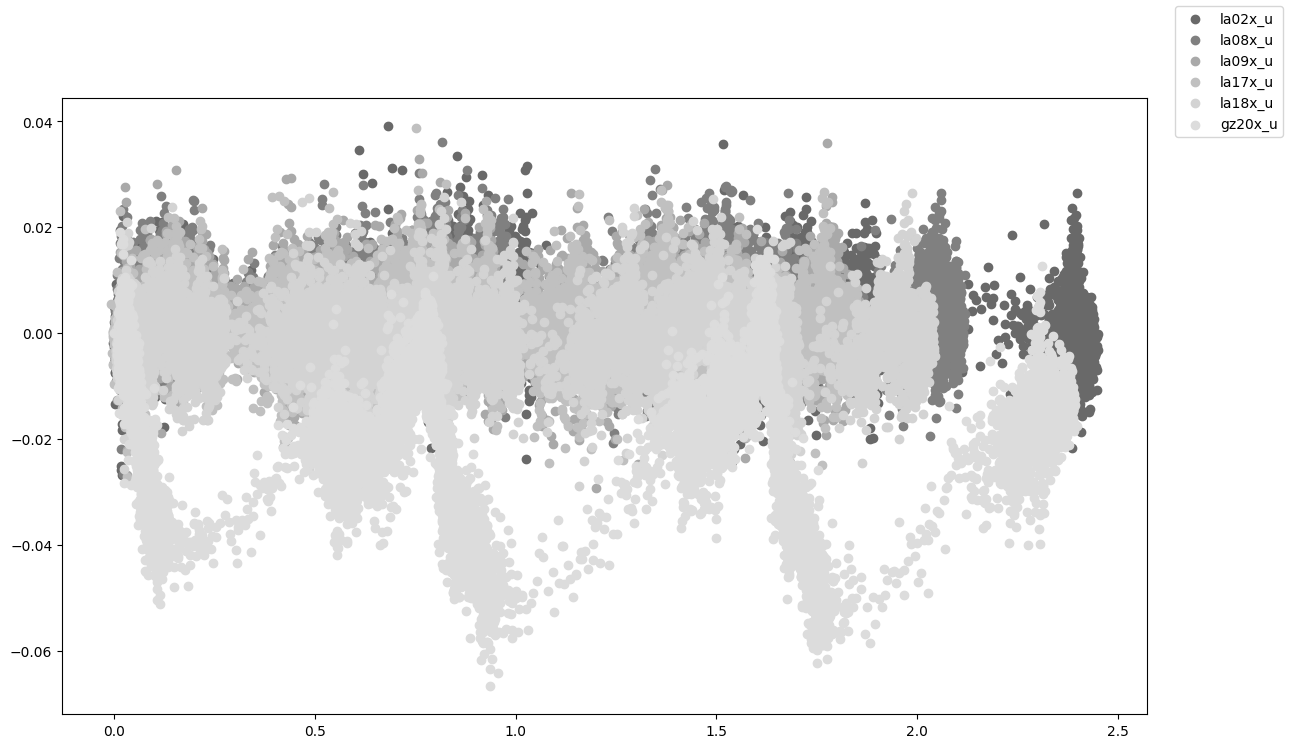

In [34]:
# Plot
u_cols = [col for col in merged if str(col).endswith("u")]
v_cols = [col for col in merged if str(col).endswith("v")]
fig, ax1 = plt.subplots(figsize=(14, 8))
colors = [
    "dimgray",
    "gray",
    "darkgray",
    "silver",
    "lightgray",
    "gainsboro",
    "dimgray",
    "gray",
    "darkgray",
    "silver",
    "lightgray",
    "gainsboro",
    "dimgray",
    "gray",
    "darkgray",
    "silver",
    "lightgray",
    "gainsboro",
    "dimgray",
    "gray",
    "darkgray",
    "silver",
    "lightgray",
    "gainsboro",
    "dimgray",
    "gray",
    "darkgray",
    "silver",
    "lightgray",
    "gainsboro",
    "dimgray",
    "gray",
    "darkgray",
    "silver",
    "lightgray",
    "gainsboro",
]
j = 0
for u_col, v_col in zip(u_cols, v_cols):
    ax1.scatter(
        merged[u_col]
        - np.mean(merged[u_col])
        - np.ones_like(merged[u_col])
        * (merged[u_col].iloc[0] - np.mean(merged[u_col])),
        merged[v_col]
        - np.mean(merged[v_col])
        - np.ones_like(merged[v_col])
        * (merged[v_col].iloc[0] - np.mean(merged[v_col])),
        color=colors[j],
        label=u_col,
    )
    j += 1

fig.legend()